[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Advanced/Lab_Notebooks/advanced_03_conformal_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Advanced Module A3 — Conformal Prediction
## Lab: split conformal on Wage, coverage over splits, adaptive intervals (CQR), prediction sets, the OLS stress test

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser, HSBI
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com). This advanced module extends the book with distribution-free prediction intervals (Vovk et al. 2005; Lei et al. 2018; Romano et al. 2019).

**Goal.** Build a split-conformal 90% interval on `Wage` in ten lines and check its coverage; watch the marginal guarantee hold over 200 repeated splits; make the interval width adaptive with locally weighted scores and conformalized quantile regression; turn softmax probabilities into prediction *sets* for a 3-class problem; and stress-test Chapter 3's OLS prediction interval against conformal under heteroskedastic truth.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. Split conformal on Wage

The whole recipe: fit on the training set *only*; compute absolute residuals on a held-out calibration set; take the $k$-th smallest with $k = \lceil (n+1)(1-\alpha)\rceil$ — the finite-sample correction that makes the guarantee exact; report $\hat f(x) \pm \hat q$. With $n = 500$, $\alpha = 0.1$: $k = \lceil 501 \times 0.9 \rceil = 451$, the $0.902$ quantile — slightly *above* the naive $0.9$ quantile.

In [2]:
from sklearn.linear_model import LinearRegression

Wage = load('Wage')
x, y_w = Wage['age'].to_numpy(float), Wage['wage'].to_numpy()
rng = np.random.default_rng(2024)                # reproducible split
i = rng.permutation(len(y_w))
tr, ca, te = i[:2000], i[2000:2500], i[2500:]    # 2000 / 500 / 500
P = lambda a: np.column_stack([a, a**2])         # quadratic in age

f = LinearRegression().fit(P(x[tr]), y_w[tr])    # 1. fit on TRAIN only
s = np.abs(y_w[ca] - f.predict(P(x[ca])))        # 2. calibration scores
k = int(np.ceil((len(ca) + 1) * (1 - 0.1)))      # 3. k = ceil((n+1)(1-alpha))
qhat = np.sort(s)[k - 1]                         #    k-th smallest score
res_te = np.abs(y_w[te] - f.predict(P(x[te])))
cov = (res_te <= qhat).mean()                    # 4. check on the test set
print(f'k = {k},  qhat = {qhat:.2f},  test coverage = {cov:.3f}')

# The textbook alternative: a Gaussian band from the training residual sd.
sig_tr = (y_w[tr] - f.predict(P(x[tr]))).std()
print(f'Gaussian band +-{1.645*sig_tr:.1f} covers {(res_te <= 1.645*sig_tr).mean():.3f} (claiming 0.90)')

k = 451,  qhat = 56.14,  test coverage = 0.926
Gaussian band +-66.1 covers 0.952 (claiming 0.90)


**Reading the output.** The 451st of 500 sorted calibration residuals gives $\hat q = 56.14$; the band $\hat f(\text{age}) \pm 56.1$ covers $92.6\%$ of the 500 test wages. The Gaussian band ($\pm 66.1$) *claims* 90% but delivers 95.2% — miscalibrated, because wages are right-skewed, not Gaussian. Conformal needed no distributional assumption: only exchangeability and a clean split.

coverage under-30s: 0.986   (n = 74)
coverage 60-plus:   0.829   (n = 35)


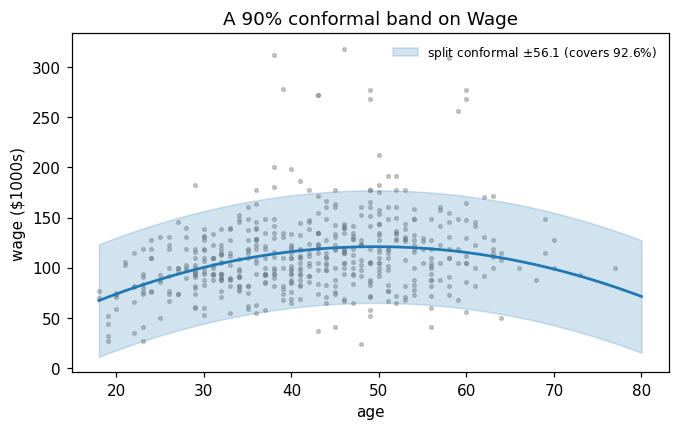

In [3]:
# Marginal is not conditional: same interval, different subgroups.
young, old = x[te] < 30, x[te] >= 60
print(f'coverage under-30s: {(res_te[young] <= qhat).mean():.3f}   (n = {young.sum()})')
print(f'coverage 60-plus:   {(res_te[old] <= qhat).mean():.3f}   (n = {old.sum()})')

fig, ax = plt.subplots(figsize=(7, 4))
grid = np.linspace(18, 80, 200)
fhat = f.predict(P(grid))
ax.scatter(x[te], y_w[te], s=6, alpha=0.4, color='grey')
ax.fill_between(grid, fhat - qhat, fhat + qhat, alpha=0.2, color='C0',
                label=fr'split conformal $\pm${qhat:.1f} (covers {cov:.1%})')
ax.plot(grid, fhat, color='C0', lw=1.8)
ax.set(xlabel='age', ylabel='wage ($1000s)', title='A 90% conformal band on Wage')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the output.** The guarantee is **marginal**: $98.6\%$ coverage for under-30s, $82.9\%$ for the 60-plus group, $92.6\%$ on average. A constant-width band overcovers where wages are predictable and undercovers where they spread out. If a subgroup matters, calibrate on that subgroup (Mondrian conformal) or use adaptive scores — Section 3.

## 2. Coverage over repeated splits

What "$P(Y \in C(X)) \ge 0.9$" actually promises: an average over calibration draws *and* test points. Any single split can land at $0.87$ — nothing is wrong when it does. 200 random splits make the point.

coverage over 200 splits: mean 0.8976   sd 0.0198   min 0.826   max 0.940


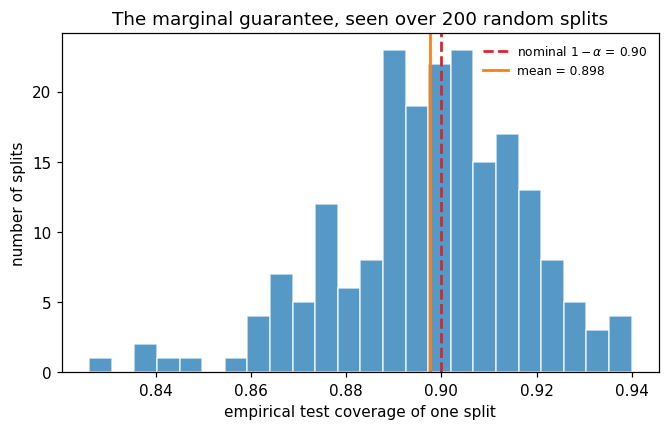

In [4]:
rng2 = np.random.default_rng(2024)
covs = []
for _ in range(200):
    p = rng2.permutation(len(Wage))
    tr2, ca2, te2 = p[:2000], p[2000:2500], p[2500:]
    m = LinearRegression().fit(P(x[tr2]), y_w[tr2])
    q = np.sort(np.abs(y_w[ca2] - m.predict(P(x[ca2]))))[k - 1]
    covs.append((np.abs(y_w[te2] - m.predict(P(x[te2]))) <= q).mean())
covs = np.array(covs)
print(f'coverage over 200 splits: mean {covs.mean():.4f}   sd {covs.std():.4f}'
      f'   min {covs.min():.3f}   max {covs.max():.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(covs, bins=24, color='C0', alpha=0.75, edgecolor='white')
ax.axvline(0.90, color='C3', ls='--', lw=1.8, label=r'nominal $1-\alpha$ = 0.90')
ax.axvline(covs.mean(), color='C1', lw=1.8, label=f'mean = {covs.mean():.3f}')
ax.set(xlabel='empirical test coverage of one split', ylabel='number of splits',
       title='The marginal guarantee, seen over 200 random splits')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the output.** Per-split coverage fluctuates between $0.826$ and $0.940$ (sd $\approx 0.02$), but the mean is $0.898 \approx 0.9$ — the guarantee in action. The deck's appendix derives the exact law of this fluctuation (a Beta distribution); with $n = 500$ calibration points its sd is $\approx 1.3\%$, which is why $n$ between 500 and 1000 is the usual sweet spot.

## 3. Adaptive intervals

One width for everyone is a blunt instrument. Two repairs, same calibration machinery:
- **locally weighted**: scale the score by a fitted spread model, $s_i = |y_i - \hat f(x_i)| / \hat\sigma(x_i)$;
- **CQR** (conformalized quantile regression): fit quantile regressions $\hat q_{0.05}, \hat q_{0.95}$, score $s_i = \max(\hat q_{lo}(x_i) - y_i,\; y_i - \hat q_{hi}(x_i))$, and shift both ends by the conformal $\hat q$.

In [5]:
from sklearn.ensemble import GradientBoostingRegressor

# Locally weighted: spread model = mean absolute residual, quadratic in age.
mad = LinearRegression().fit(P(x[tr]), np.abs(y_w[tr] - f.predict(P(x[tr]))))
sig_cal = np.clip(mad.predict(P(x[ca])), 1e-6, None)
q_lw = np.sort(s / sig_cal)[k - 1]               # scores in sigma-units

# CQR: gradient boosting at the 5% and 95% quantiles.
X1 = x.reshape(-1, 1)
gb = dict(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=0)
lo = GradientBoostingRegressor(loss='quantile', alpha=0.05, **gb).fit(X1[tr], y_w[tr])
hi = GradientBoostingRegressor(loss='quantile', alpha=0.95, **gb).fit(X1[tr], y_w[tr])
s_cqr = np.maximum(lo.predict(X1[ca]) - y_w[ca], y_w[ca] - hi.predict(X1[ca]))
q_cqr = np.sort(s_cqr)[k - 1]

L, U = lo.predict(X1[te]) - q_cqr, hi.predict(X1[te]) + q_cqr
cov_cqr = ((y_w[te] >= L) & (y_w[te] <= U)).mean()
print(f'q_lw = {q_lw:.3f} (sigma-units),  q_cqr = {q_cqr:.2f},  CQR test coverage = {cov_cqr:.3f}')

width = U - L; a_te = x[te]
for label, mask in [('age < 30 ', a_te < 30), ('age 30-59', (a_te >= 30) & (a_te < 60)),
                    ('age >= 60', a_te >= 60)]:
    print(f'avg width {label}:  CQR {width[mask].mean():6.1f}   constant {2*qhat:6.1f}')

q_lw = 1.897 (sigma-units),  q_cqr = 0.66,  CQR test coverage = 0.896
avg width age < 30 :  CQR   70.5   constant  112.3
avg width age 30-59:  CQR  120.4   constant  112.3
avg width age >= 60:  CQR  134.9   constant  112.3


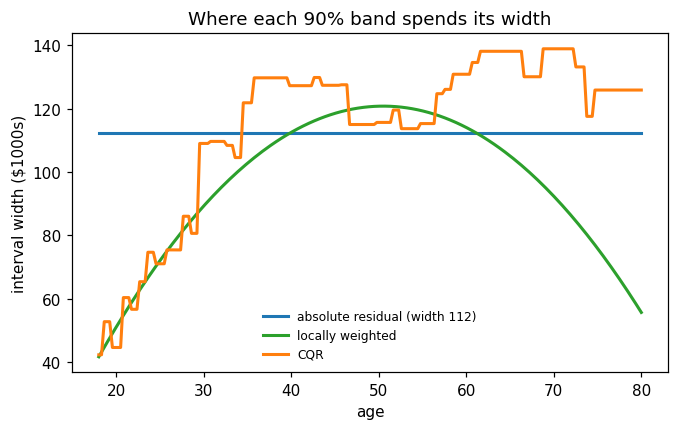

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
gsig = np.clip(mad.predict(P(grid)), 1e-6, None)
ax.plot(grid, np.full_like(grid, 2*qhat), color='C0', lw=2, label=f'absolute residual (width {2*qhat:.0f})')
ax.plot(grid, 2*q_lw*gsig, color='C2', lw=2, label='locally weighted')
ax.plot(grid, hi.predict(grid.reshape(-1, 1)) + q_cqr - (lo.predict(grid.reshape(-1, 1)) - q_cqr),
        color='C1', lw=2, label='CQR')
ax.set(xlabel='age', ylabel='interval width ($1000s)',
       title='Where each 90% band spends its width')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the output.** All three cover $\approx 90\%$ marginally (CQR: $89.6\%$), but CQR spends its width where the data spread: average width $70.5$ for under-30s against $134.9$ for 60-plus, where the constant band pays $112.3$ everywhere. Note the locally weighted curve *falls* after age 60 — its quadratic $\hat\sigma$ extrapolates poorly: the allocation is only as good as the scale model, even though marginal coverage is untouched.

## 4. Conformal classification

For classification the interval becomes a **set** of labels: score $s_i = 1 - \hat p_{y_i}(x_i)$ on the calibration set, then include in $C(x)$ every class whose predicted probability is at least $1 - \hat q$. The set *size* is a per-point difficulty meter that the accuracy number hides.

In [7]:
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(2024)
mu = np.array([[0, 0], [2.2, 0], [1.1, 1.9]])    # class centres
Xc = np.vstack([rng.normal(m, 1.0, (1000, 2)) for m in mu])
yc = np.repeat([0, 1, 2], 1000)
p = rng.permutation(3000); Xc, yc = Xc[p], yc[p] # shuffle once
TRc, CAc, TEc = np.arange(1500), np.arange(1500, 2250), np.arange(2250, 3000)

clf = LogisticRegression(max_iter=1000).fit(Xc[TRc], yc[TRc])
print(f'test accuracy of the point classifier: {(clf.predict(Xc[TEc]) == yc[TEc]).mean():.3f}')

pc = clf.predict_proba(Xc[CAc])
s_cls = 1 - pc[np.arange(750), yc[CAc]]          # 1 - p_true on calibration
k_cls = int(np.ceil(751 * 0.9))                  # k = 676
qhat_cls = np.sort(s_cls)[k_cls - 1]
sets = clf.predict_proba(Xc[TEc]) >= 1 - qhat_cls
cov_cls = sets[np.arange(750), yc[TEc]].mean()
sizes = sets.sum(axis=1)
print(f'k = {k_cls},  qhat = {qhat_cls:.4f},  coverage = {cov_cls:.4f},  avg set size = {sizes.mean():.3f}')
print(f'set sizes:  singletons {np.mean(sizes == 1):.1%},  pairs {np.mean(sizes == 2):.1%},'
      f'  full {np.mean(sizes == 3):.1%},  empty {np.mean(sizes == 0):.1%}')

test accuracy of the point classifier: 0.809
k = 676,  qhat = 0.7685,  coverage = 0.9013,  avg set size = 1.296
set sizes:  singletons 71.3%,  pairs 27.7%,  full 0.9%,  empty 0.0%


**Reading the output.** Logistic accuracy is $80.9\%$, yet the sets cover $90.1\%$ — by *saying more than one label* exactly where the classes overlap: $71\%$ singletons near the centres, $28\%$ pairs at the boundaries. The price of certainty: demanding $99\%$ coverage ($\alpha = 0.01$, $k = 744$, $\hat q = 0.9638$) inflates the average set to $2.17$ of 3 classes. Pick $\alpha$ by what a large set costs downstream — a manual review, a second lab test.

## 5. OLS prediction interval vs conformal

Chapter 3's interval is exact at every $x$ — *if* the linear-Gaussian-homoskedastic model is true. First the friendly case, where they should agree; the full heteroskedastic stress test is worked as Extended Exercise A3.2 below.

In [8]:
import statsmodels.api as sm

rng = np.random.default_rng(2024)
N = 4000
xs = rng.uniform(0, 10, N)
ys = 1 + 2*xs + rng.normal(0, 2, N)              # homoskedastic truth, sigma = 2
tr3, ca3, te3 = np.arange(2000), np.arange(2000, 3000), np.arange(3000, 4000)

ols = sm.OLS(ys[tr3], sm.add_constant(xs[tr3])).fit()
half_ols = 1.645 * np.sqrt(ols.scale)            # theory: 1.645 x 2 = 3.29
pred = ols.params[0] + ols.params[1] * xs[te3]
k3 = int(np.ceil(1001 * 0.9))
q3 = np.sort(np.abs(ys[ca3] - (ols.params[0] + ols.params[1]*xs[ca3])))[k3 - 1]
print(f'OLS PI        half-width {half_ols:.2f}   coverage {(np.abs(ys[te3]-pred) <= half_ols).mean():.3f}')
print(f'split conformal half-width {q3:.2f}   coverage {(np.abs(ys[te3]-pred) <= q3).mean():.3f}')

OLS PI        half-width 3.31   coverage 0.915
split conformal half-width 3.24   coverage 0.909


**Reading the output.** When the Gaussian linear model is *true*, conformal costs essentially nothing: both intervals reproduce the theoretical $\pm 3.29$ ($3.31$ vs $3.24$) and both cover $\approx 90\%$. Conformal is not a better interval — it is the same interval with a *weaker warranty requirement*. Validation teams run both: if they disagree materially, the model assumptions are the prime suspect.

## Lecture exercises — worked Python solutions

These are the **[Python]-tagged exercises from the lecture slides**, solved step by step; run them cell by cell and compare with the slide solutions. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Extended Exercise A3.1 — CQR on Wage, end to end [Python]

**Task (from the slides).** Reproduce the adaptive band using the deck's split of `Wage` (seed 2024; $2000/500/500$):
1. fit `GradientBoostingRegressor(loss="quantile")` at levels $0.05$ and $0.95$ on the training set (200 trees, depth 2, learning rate 0.05, `random_state=0`);
2. compute the CQR scores on the calibration set and $\hat q$ at $\alpha = 0.1$; report test coverage;
3. compare average interval width for ages $<30$, $30$–$59$ and $\ge 60$ against the constant-width band ($112.3$);
4. compare the two bands' *subgroup coverage* for under-30s and 60-plus — which failure does CQR repair, and what does it *not* guarantee?

In [9]:
# (1)-(2): the models and scores were fitted in Section 3 — recompute explicitly.
s_cqr = np.maximum(lo.predict(X1[ca]) - y_w[ca], y_w[ca] - hi.predict(X1[ca]))  # CQR score
k = int(np.ceil((len(ca) + 1) * 0.9))            # k = 451
qhat_cqr = np.sort(s_cqr)[k - 1]                 # tiny correction
L, U = lo.predict(X1[te]) - qhat_cqr, hi.predict(X1[te]) + qhat_cqr
print(round(qhat_cqr, 2), ((y_w[te] >= L) & (y_w[te] <= U)).mean())   # Expected: 0.66 0.896

# (3) --------------------------------------------------------------------
width = U - L
for label, mask in [('age < 30 ', a_te < 30), ('age 30-59', (a_te >= 30) & (a_te < 60)),
                    ('age >= 60', a_te >= 60)]:
    print(f'{label}:  CQR width {width[mask].mean():6.1f}   constant {2*qhat:6.1f}')

# (4) --------------------------------------------------------------------
in_cqr = (y_w[te] >= L) & (y_w[te] <= U)
in_const = res_te <= qhat
for label, mask in [('under-30', a_te < 30), ('60-plus ', a_te >= 60)]:
    print(f'{label}:  constant {in_const[mask].mean():.3f}   CQR {in_cqr[mask].mean():.3f}')

0.66 0.896
age < 30 :  CQR width   70.5   constant  112.3
age 30-59:  CQR width  120.4   constant  112.3
age >= 60:  CQR width  134.9   constant  112.3
under-30:  constant 0.986   CQR 0.797
60-plus :  constant 0.829   CQR 0.886


**Reading the output.** $\hat q = 0.66$ — a tiny correction, because the quantile model already spans $\approx 90\%$ — and test coverage $0.896$. CQR repairs the *width misallocation*: it stops wasting 40 units of width on the young ($70.5$ vs $112.3$) and reinvests them in the old, whose coverage rises from $0.829$ to $0.886$. What it does **not** guarantee: exact per-group coverage — the young bin ($n = 74$) lands at $0.797$, within sampling noise of $0.9$ but not pinned to it. Only the marginal $90\%$ is guaranteed; per-group guarantees need per-group calibration. And the slide's warning stands: fit the quantile models on training data only — refitting on calibration data voids the guarantee.

### Extended Exercise A3.2 — Stress-testing the two intervals [Integrative]

**Task (from the slides).** Simulate $y = 1 + 2x + x\,\varepsilon$, $\varepsilon \sim \mathcal N(0,1)$, $x \sim U(0,10)$, $n = 4000$ (split $2000/1000/1000$, seed 2024):
1. fit OLS; build the 90% prediction interval $\hat y \pm 1.645\,\hat\sigma$; measure test coverage overall, for $x<2$, and for $x>8$;
2. build the split-conformal interval (absolute residuals, $\alpha = 0.1$) and measure the same three coverages — what does conformal fix, and what not?
3. fit a 500-tree `GradientBoostingRegressor`; report coverage of $\hat f \pm 1.645 \times \text{sd(training residuals)}$, then conformalise the same model — explain the gap;
4. which failure modes does split conformal repair marginally, and which needs CQR?

In [10]:
rng = np.random.default_rng(2024)
N = 4000
xh = rng.uniform(0, 10, N)
yh = 1 + 2*xh + xh*rng.normal(0, 1, N)           # noise GROWS with x
tr4, ca4, te4 = np.arange(2000), np.arange(2000, 3000), np.arange(3000, 4000)
cov3 = lambda hit: [round(float(hit.mean()), 3), round(float(hit[xh[te4] < 2].mean()), 3),
                    round(float(hit[xh[te4] > 8].mean()), 3)]

# (1) OLS with a pooled sigma ---------------------------------------------
ols = sm.OLS(yh[tr4], sm.add_constant(xh[tr4])).fit()
half = 1.645 * np.sqrt(ols.scale)
pred = ols.params[0] + ols.params[1] * xh[te4]
print(f'(1) pooled sigma {np.sqrt(ols.scale):.2f}   [overall, x<2, x>8] =',
      cov3(np.abs(yh[te4] - pred) <= half))

# (2) conformalise the same OLS model -------------------------------------
kx = int(np.ceil(1001 * 0.9))                    # k = 901
q = np.sort(np.abs(yh[ca4] - (ols.params[0] + ols.params[1]*xh[ca4])))[kx - 1]
print(f'(2) conformal qhat {q:.2f}          [overall, x<2, x>8] =',
      cov3(np.abs(yh[te4] - pred) <= q))

# (3) flexible model, optimistic plug-in sigma vs conformal ----------------
g = GradientBoostingRegressor(n_estimators=500, random_state=0).fit(xh[tr4, None], yh[tr4])
sig_tr4 = np.std(yh[tr4] - g.predict(xh[tr4, None]))
print(f'(3) GBR training-residual sd {sig_tr4:.2f}  (held-out sd {np.std(yh[te4] - g.predict(xh[te4, None])):.2f})')
print(f'    plug-in   [overall, x<2, x>8] =', cov3(np.abs(yh[te4] - g.predict(xh[te4, None])) <= 1.645*sig_tr4))
qg = np.sort(np.abs(yh[ca4] - g.predict(xh[ca4, None])))[kx - 1]
print(f'    conformal (qhat {qg:.2f})       =', cov3(np.abs(yh[te4] - g.predict(xh[te4, None])) <= qg))

(1) pooled sigma 5.87   [overall, x<2, x>8] = [0.906, 1.0, 0.735]
(2) conformal qhat 9.79          [overall, x<2, x>8] = [0.908, 1.0, 0.741]
(3) GBR training-residual sd 3.92  (held-out sd 6.12)


    plug-in   [overall, x<2, x>8] = [0.776, 1.0, 0.46]
    conformal (qhat 10.81)       = [0.907, 1.0, 0.709]


**Reading the output.**
1. OLS: marginal $0.906$, but $100\%$ for $x<2$ and $73.5\%$ for $x>8$ — the pooled $\hat\sigma = 5.87$ is one compromise width for noise that ranges from $\approx 0$ to $10$.
2. Conformal ($\hat q = 9.79$): marginal $0.908$, subgroups $1.00 / 0.741$ — conformal *guarantees the marginal number*, but a constant-width score cannot repair the conditional imbalance; that is CQR's job.
3. The plug-in GBR claims 90% and delivers $77.6\%$: the training-residual sd ($3.92$) understates the held-out error sd ($6.12$) because 500 trees partly memorised the training noise. Conformalising the *same* model restores $90.7\%$ by pricing the width on unseen data ($\hat q = 10.81$).
4. Marginal repairs come free — skew, heteroskedasticity and optimism are all handled; *conditional* honesty across $x$ is the one thing that needs an adaptive score. And do not conclude that conformal "failed" in part 2: expecting per-region coverage from a constant-width score is a specification error, not a method error.

### Exercise A3.5 — Conformal classification from scratch [Python]

**Task (from the slides).** Build prediction sets for the deck's 3-class simulation (three Gaussian classes, 1000 points each, centres $(0,0)$, $(2.2,0)$, $(1.1,1.9)$, unit variance, seed 2024; split $1500/750/750$):
1. fit `LogisticRegression` on the training set;
2. compute the calibration scores $s_i = 1 - \hat p_{y_i}(x_i)$ and $\hat q$ at $\alpha = 0.1$ (which $k$?);
3. build the test-set prediction sets; report coverage, average set size and the share of singletons;
4. re-run with $\alpha = 0.01$ — what happens to the average set size?

In [11]:
# (1)-(3): the pipeline of Section 4, condensed to the slide's ten lines.
rng = np.random.default_rng(2024)
mu = np.array([[0, 0], [2.2, 0], [1.1, 1.9]])    # class centres
Xs_ = np.vstack([rng.normal(m, 1.0, (1000, 2)) for m in mu])
ys_ = np.repeat([0, 1, 2], 1000)
p = rng.permutation(3000); Xs_, ys_ = Xs_[p], ys_[p]
clf = LogisticRegression(max_iter=1000).fit(Xs_[:1500], ys_[:1500])
pc = clf.predict_proba(Xs_[1500:2250])           # calibration probs
s = 1 - pc[np.arange(750), ys_[1500:2250]]       # 1 - p_true (NOT 1 - max p!)
k = int(np.ceil(751 * 0.9))                      # k = 676
qhat_c = np.sort(s)[k - 1]
sets = clf.predict_proba(Xs_[2250:]) >= 1 - qhat_c
cov_c = sets[np.arange(750), ys_[2250:]].mean()
print(round(qhat_c, 4), cov_c, sets.sum(1).mean().round(3))   # Expected: 0.7685 0.9013 1.296
print(f'singletons: {np.mean(sets.sum(1) == 1):.1%}')

# (4) --------------------------------------------------------------------
k99 = int(np.ceil(751 * 0.99))
q99 = np.sort(s)[k99 - 1]
sets99 = clf.predict_proba(Xs_[2250:]) >= 1 - q99
print(f'alpha = 0.01:  k = {k99},  qhat = {q99:.4f},  '
      f'coverage = {sets99[np.arange(750), ys_[2250:]].mean():.4f},  avg size = {sets99.sum(1).mean():.2f}')

0.7685 0.9013333333333333 1.296
singletons: 71.3%
alpha = 0.01:  k = 744,  qhat = 0.9638,  coverage = 0.9893,  avg size = 2.17


**Reading the output.** $k = 676$ of 751, $\hat q = 0.7685$: a test class enters the set whenever its predicted probability exceeds $1 - \hat q = 0.2315$. Coverage $0.9013$, average size $1.30$, $71.3\%$ singletons. At $\alpha = 0.01$ the sets swell to $2.17$ of 3 classes — certainty is bought with set size. And mind the slide's trap: the score uses $1 - \hat p_{y_i}$ for the **true** class, not the predicted one — the score must know the truth on the calibration set; that is what it is for.

## 6. Exercises

1. In Section 1, replace the quadratic model with a 10th-degree polynomial. What happens to $\hat q$ and to coverage — and why does overfitting *not* break the guarantee?
2. Shrink the calibration set to $n = 50$ and repeat Section 2's 200-split experiment. How does the spread of per-split coverage react, and what does the $n \ge 1/\alpha - 1$ rule say about $\alpha = 0.01$ here?
3. In Section 4, switch the score to $1 - \max_k \hat p_k$ (the predicted class) and measure coverage. How badly does the wrong score miss, and why?
4. Build a Mondrian variant of Section 1: calibrate separately for ages $<40$ and $\ge 40$, and compare subgroup coverage with the single-calibration band.